In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_vna_csv(path):
    df = pd.read_csv(path,sep=';',skiprows=2)

    # The first 3 rows refer to freq、re、im
    df = df.iloc[:, :3]
    df.columns = ["freq_Hz", "re_S21", "im_S21"]
    for col in ["freq_Hz", "re_S21", "im_S21"]:
        df[col] = pd.to_numeric(df[col], errors='coerce')


    # Calculate |S21|
    df["mag"] = np.sqrt(df["re_S21"]**2 + df["im_S21"]**2)
    df["mag_dB"] = 20 * np.log10(df["mag"])
    df["freq_GHz"] = df["freq_Hz"] / 1e9

    return df

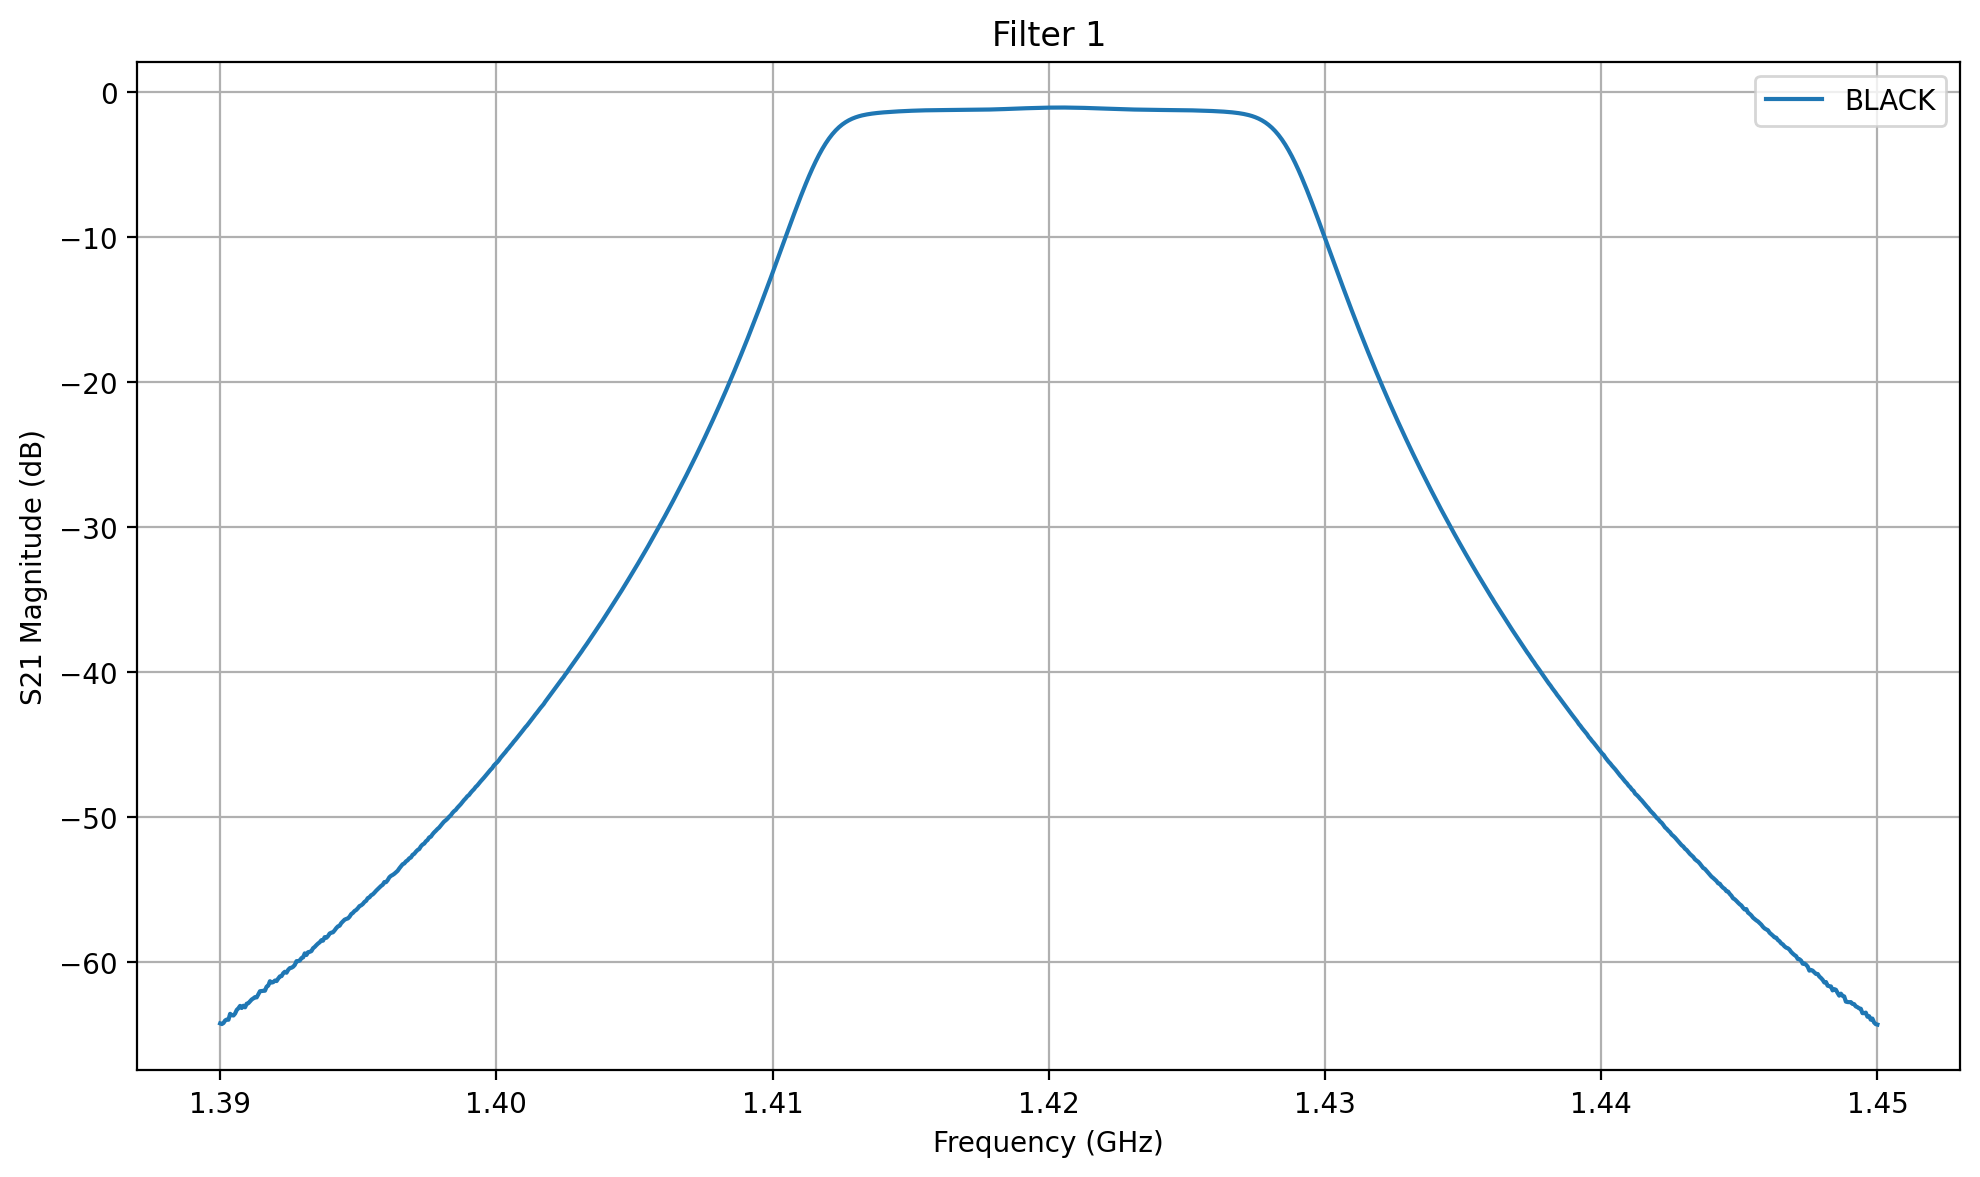

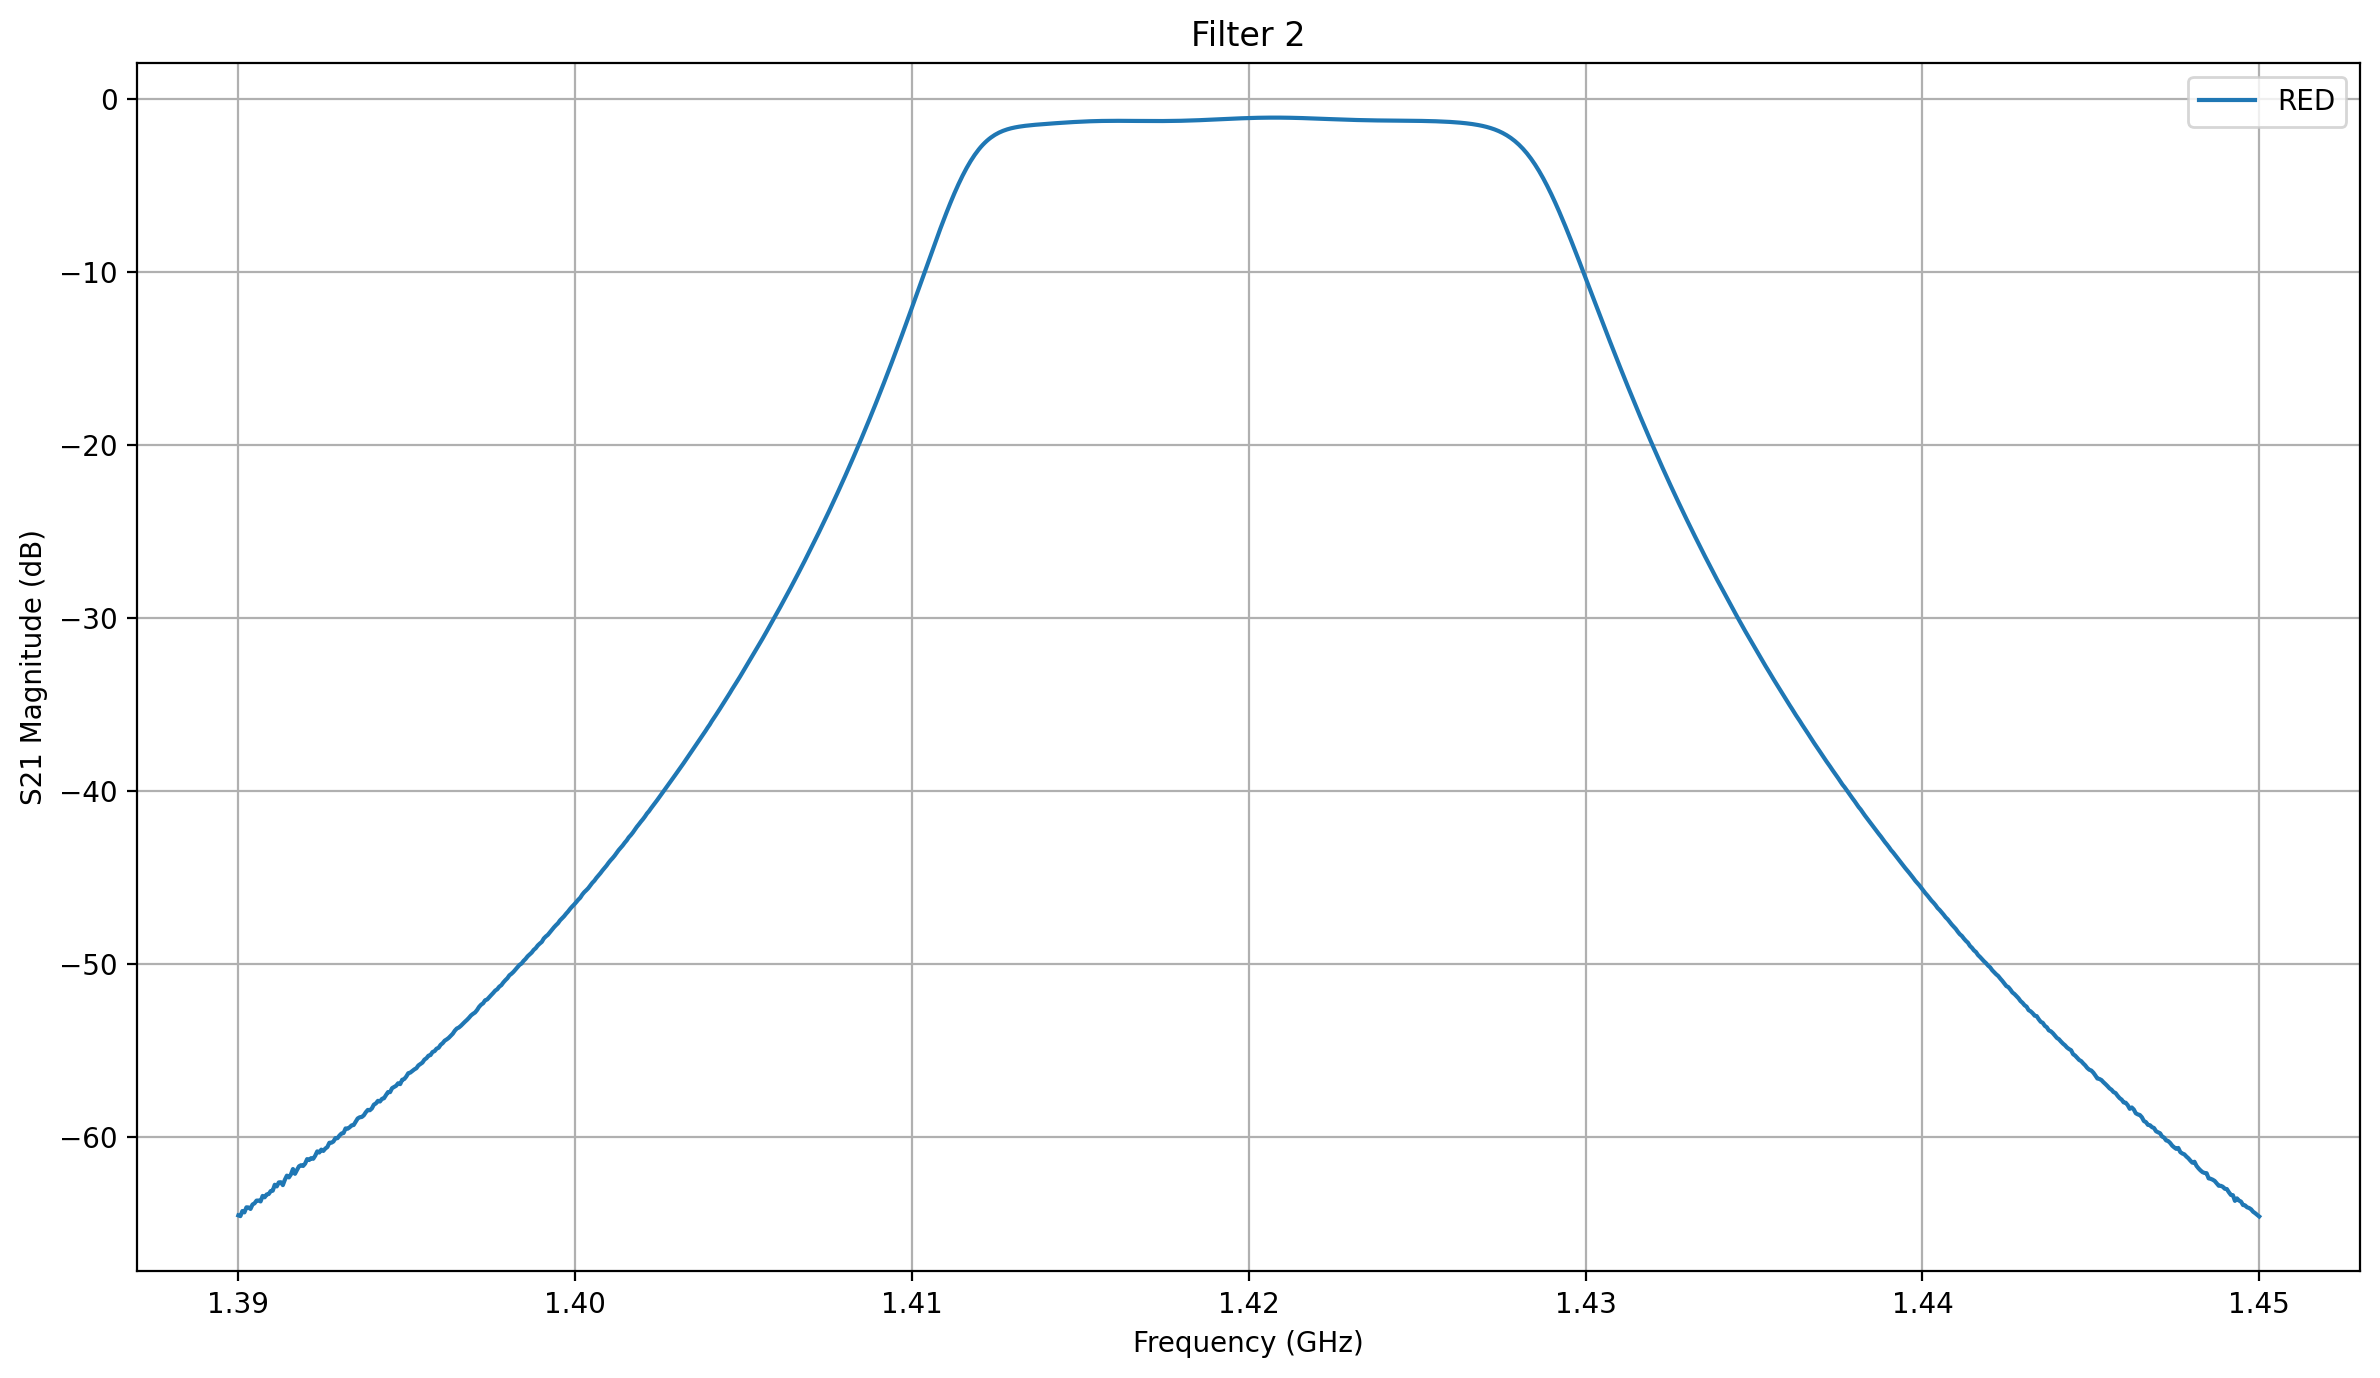

In [4]:
amp1 = load_vna_csv("2025.11.20(1604)RED.csv")
amp2 = load_vna_csv("2025.11.20(1631)BLACK.csv")

plt.figure(figsize=(10, 6))
plt.plot(amp2["freq_GHz"], amp2["mag_dB"], label="BLACK")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Filter 1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure
plt.plot(amp1["freq_GHz"], amp1["mag_dB"], label="RED")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Filter 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

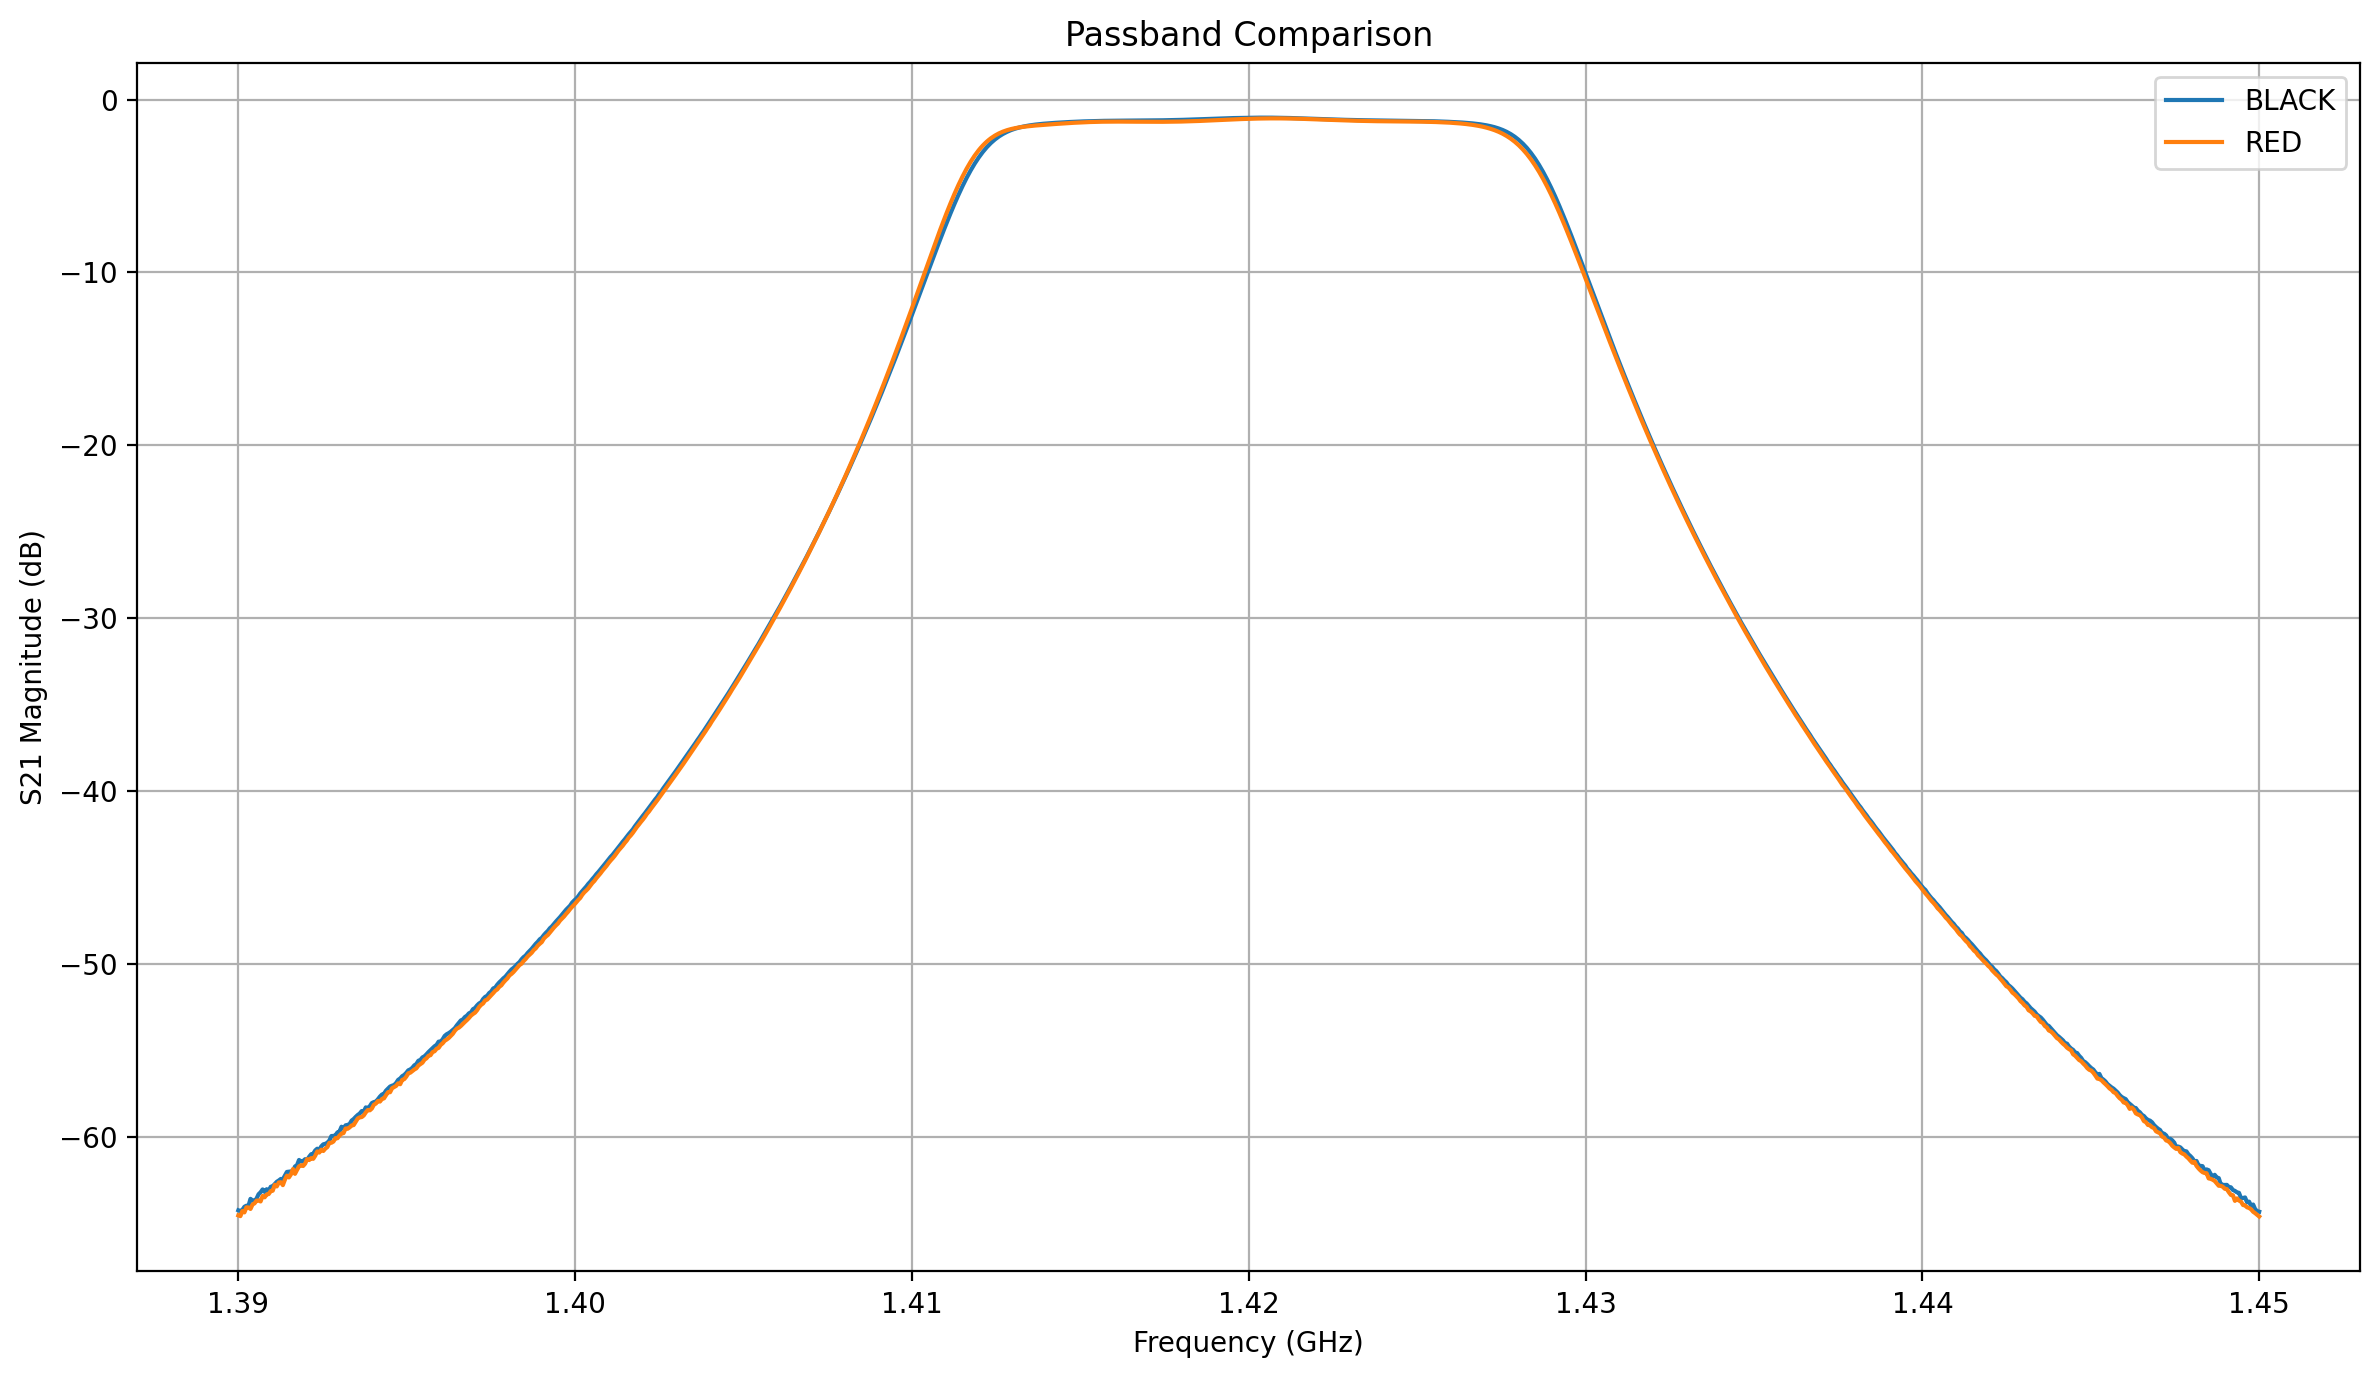

In [5]:
plt.plot(amp2["freq_GHz"], amp2["mag_dB"], label="BLACK")
plt.plot(amp1["freq_GHz"], amp1["mag_dB"], label="RED")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Passband Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
#-3dB

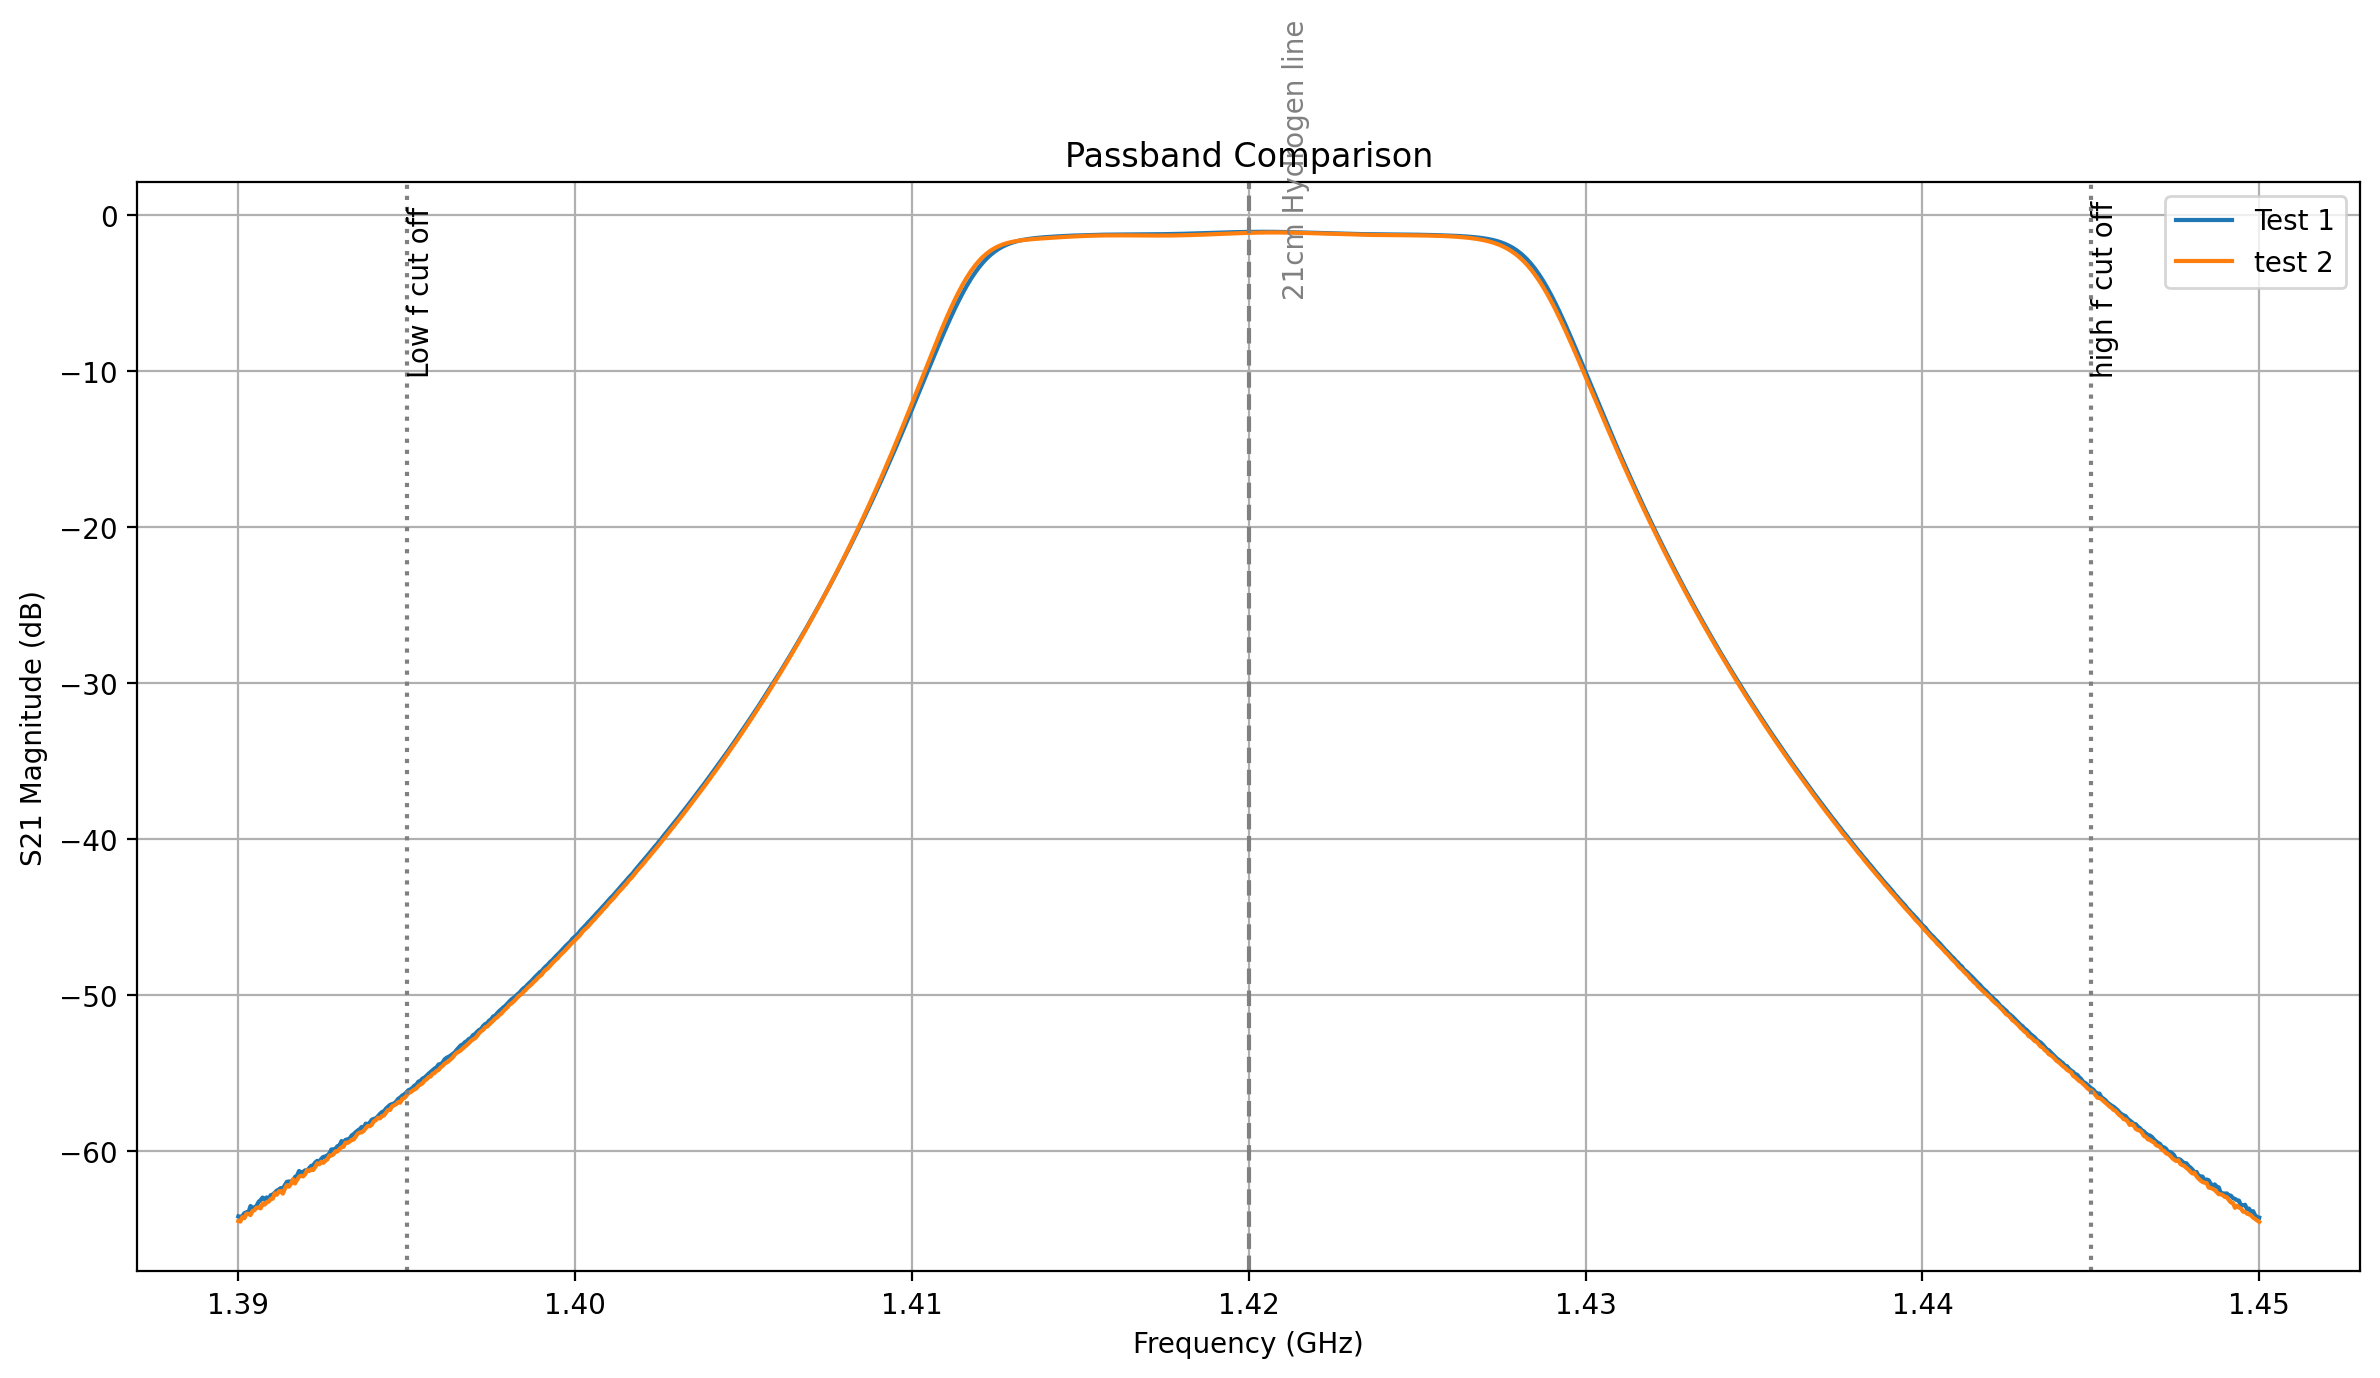

In [6]:
plt.plot(amp2["freq_GHz"], amp2["mag_dB"], label="Test 1")
plt.plot(amp1["freq_GHz"], amp1["mag_dB"], label="test 2") #opposite!!


#plt.plot(filter_freq, filter_s21, '--', label="manufacturer’s data")


plt.axvline(1.420, linestyle="--", color="gray")
plt.text(1.421, -5, "21cm Hydrogen line", rotation=90, color="gray")


plt.axvline(1.395, linestyle=":", color="gray")
plt.axvline(1.445, linestyle=":", color="gray")
plt.text(1.395, -10, "Low f cut off", rotation=90)
plt.text(1.445, -10, "high f cut off", rotation=90)

plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Magnitude (dB)")
plt.title("Passband Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
def plot_passband(df, title):
    df = df.copy()

    # normalize
    peak = df["mag_dB"].max()
    df["mag_norm_dB"] = df["mag_dB"] - peak
    
    passband = df[df["mag_norm_dB"] >= -3]
    passband1 = df[df["mag_norm_dB"] >= -2.5]

    f_low = passband["freq_GHz"].min()
    f_high = passband["freq_GHz"].max()
    BW = f_high - f_low

    f_low1 = passband1["freq_GHz"].min()
    f_high1 = passband1["freq_GHz"].max()
    BW1 = f_high1 - f_low1

    # uncertainties
    mag_err = 0.01
    ppm = 1e-6
    freq_err = ppm * df["freq_GHz"]


    
    df_step = df["freq_GHz"].diff().dropna()
    delta_f = df_step.median()          # GHz
    sample_err = delta_f / 2            # GHz

    err_low = np.sqrt(sample_err**2 + (ppm * f_low)**2)
    err_high = np.sqrt(sample_err**2 + (ppm * f_high)**2)
    BW_err = np.sqrt(err_low**2 + err_high**2)

    err_low1 = np.sqrt(sample_err**2 + (ppm * f_low1)**2)
    err_high1 = np.sqrt(sample_err**2 + (ppm * f_high1)**2)
    BW1_err = np.sqrt(err_low1**2 + err_high1**2)

    # MHz
    BW_MHz = BW * 1e3
    BW1_MHz = BW1 * 1e3
    BW_err_MHz = BW_err * 1e3
    BW1_err_MHz = BW1_err * 1e3

    # first 
    plt.figure(figsize=(10, 6))
    plt.errorbar(df["freq_GHz"], df["mag_norm_dB"],yerr=mag_err, xerr=freq_err,fmt='-', linewidth=1.2, elinewidth=0.5, capsize=2,
                 label=r"Systematic uncertainty: $Normalised S|21|=\pm 0.01$ dB, $frequency=\pm 1$ ppm")

    plt.axhline(-3, linestyle='--', color='red', label='-3 dB')
    plt.axvspan(f_low, f_high, alpha=0.1, label='-3 dB Passband')
    plt.axvline(f_low, linestyle='--')
    plt.axvline(f_high, linestyle='--')

    plt.text(f_low, -0.5, f"{f_low:.3f} GHz", color='red', ha='right')
    plt.text(f_high, -0.5, f"{f_high:.3f} GHz", color='red', ha='left')
    plt.text((f_low + f_high) / 2, -6,f"BW = {BW_MHz:.2f} ± {BW_err_MHz:.2f} MHz",ha='center', fontsize=12)

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Normalized |S21| (dB)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # second
    plt.figure(figsize=(10, 6))
    plt.errorbar(df["freq_GHz"], df["mag_norm_dB"],yerr=mag_err, xerr=freq_err,fmt='-', linewidth=1.2, elinewidth=0.5, capsize=2,
                 label=r"$Normalised S|21|=\pm 0.01$ dB, $frequency=\pm 1$ ppm")

    plt.axhline(-3, linestyle='--', color='red', label='-3 dB')
    plt.axhline(-2.5, linestyle='--', color='blue', label='-2.5 dB')

    plt.axvspan(f_low, f_high, color='pink', alpha=0.6, label='-3 dB Passband')
    plt.axvspan(f_low1, f_high1, color='orange', alpha=0.2, label='-2.5 dB Passband')

    plt.axvline(f_low, linestyle='--', color='red')
    plt.axvline(f_high, linestyle='--', color='red')
    plt.axvline(f_low1, linestyle='--', color='blue')
    plt.axvline(f_high1, linestyle='--', color='blue')

    plt.text(f_low, -2.9, f"{f_low:.4f} GHz", color='red', ha='right')
    plt.text(f_high, -2.9, f"{f_high:.4f} GHz", color='red', ha='left')
    plt.text(f_low1, -2.4, f"{f_low1:.4f} GHz", color='blue', ha='right')
    plt.text(f_high1, -2.4, f"{f_high1:.4f} GHz", color='blue', ha='left')

    plt.text((f_low + f_high) / 2, -0.5,f"-3 dB BW = {BW_MHz:.2f} ± {BW_err_MHz:.2f} MHz",ha='center',  fontsize=13)

    plt.text((f_low1 + f_high1) / 2, -0.7,f"-2.5 dB BW = {BW1_MHz:.2f} ± {BW1_err_MHz:.2f} MHz",ha='center',  fontsize=13)

    plt.xlabel("Frequency (GHz)",fontsize=14)
    plt.ylabel("Normalized |S21| (dB)",fontsize=14)
    plt.xlim(1.4113, 1.429)
    plt.ylim(-3.5, 0.15)
    plt.title(f"{title}: -3 dB and -2.5 dB Passband Comparison",fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return f_low, f_high, BW_MHz, BW_err_MHz, f_low1, f_high1, BW1_MHz, BW1_err_MHz

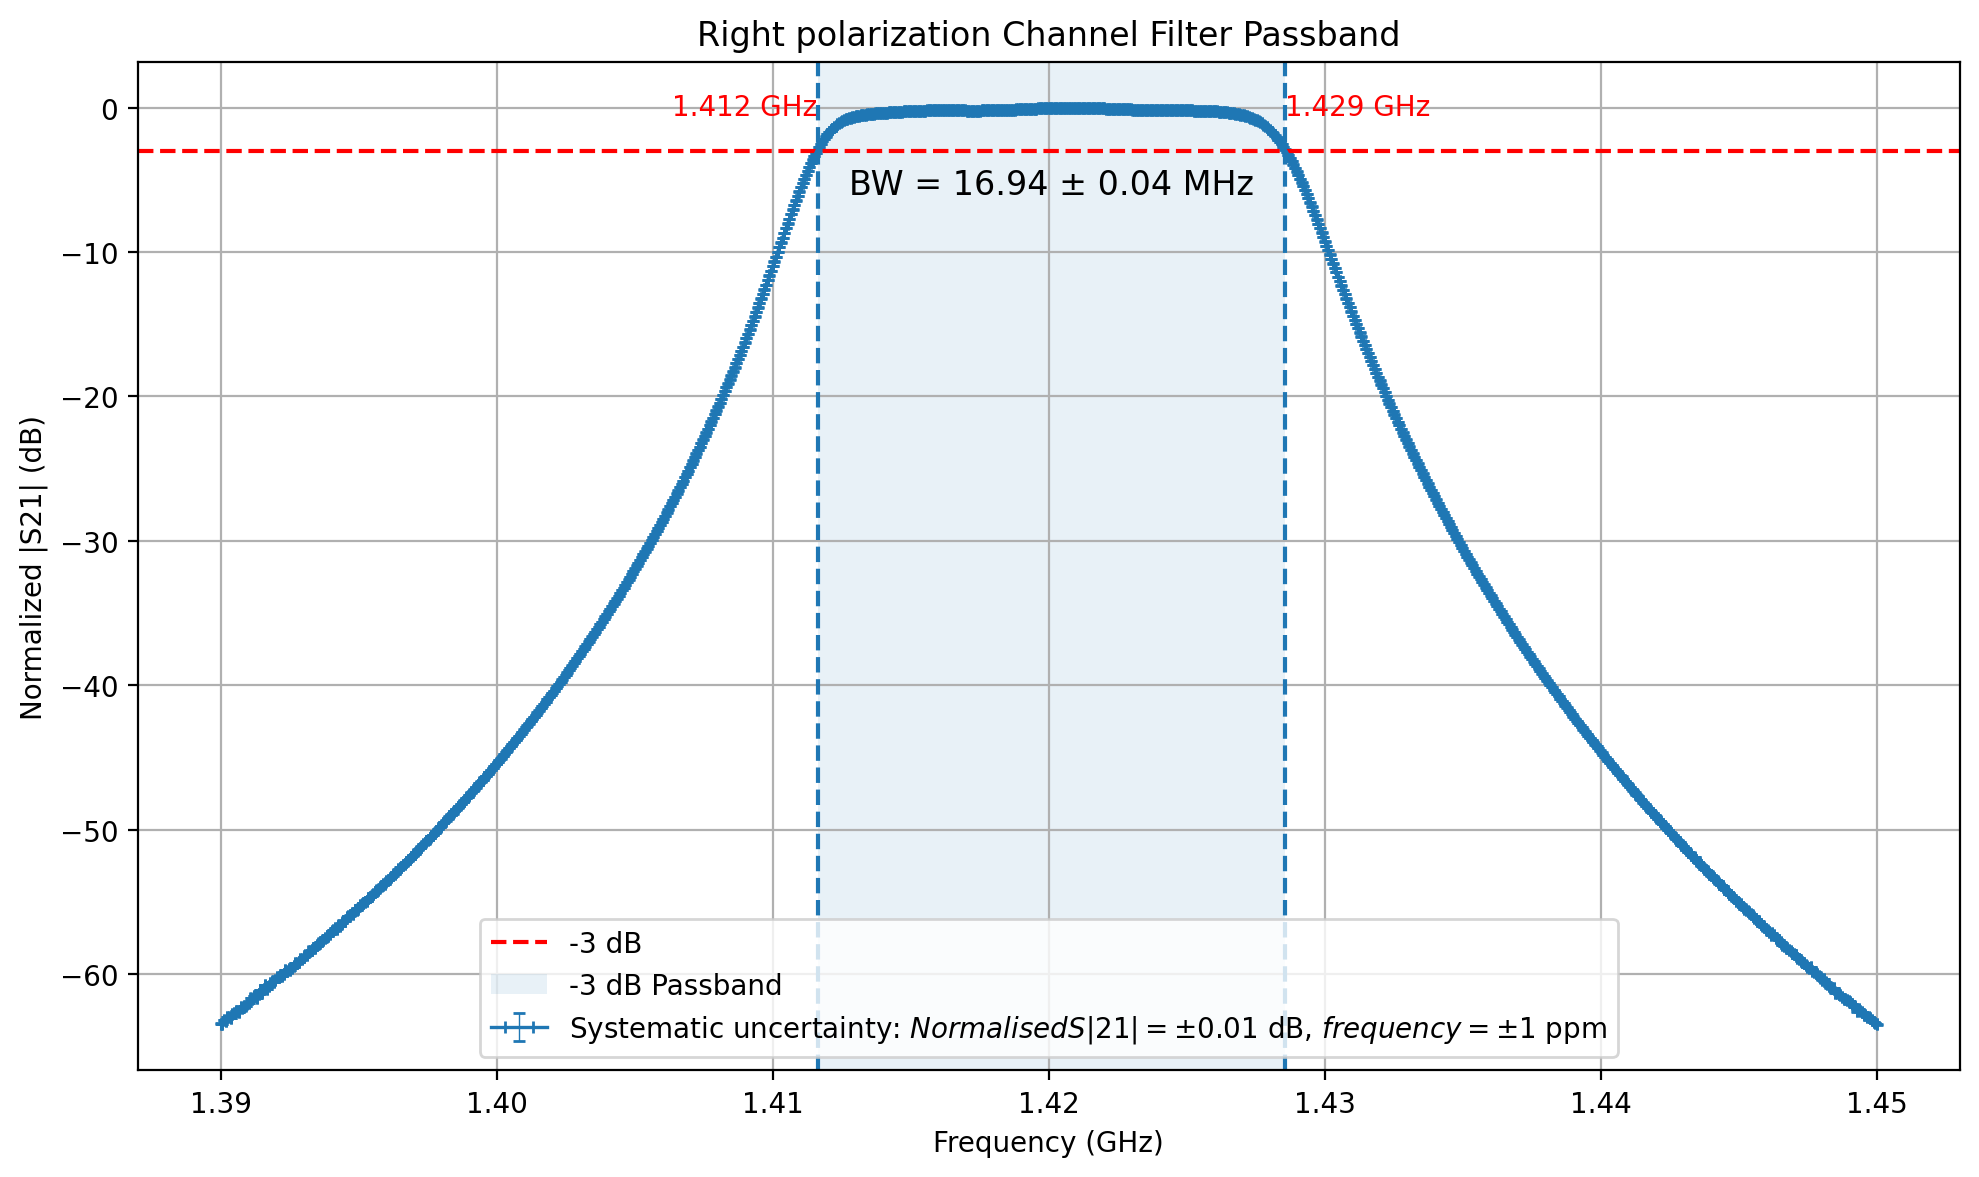

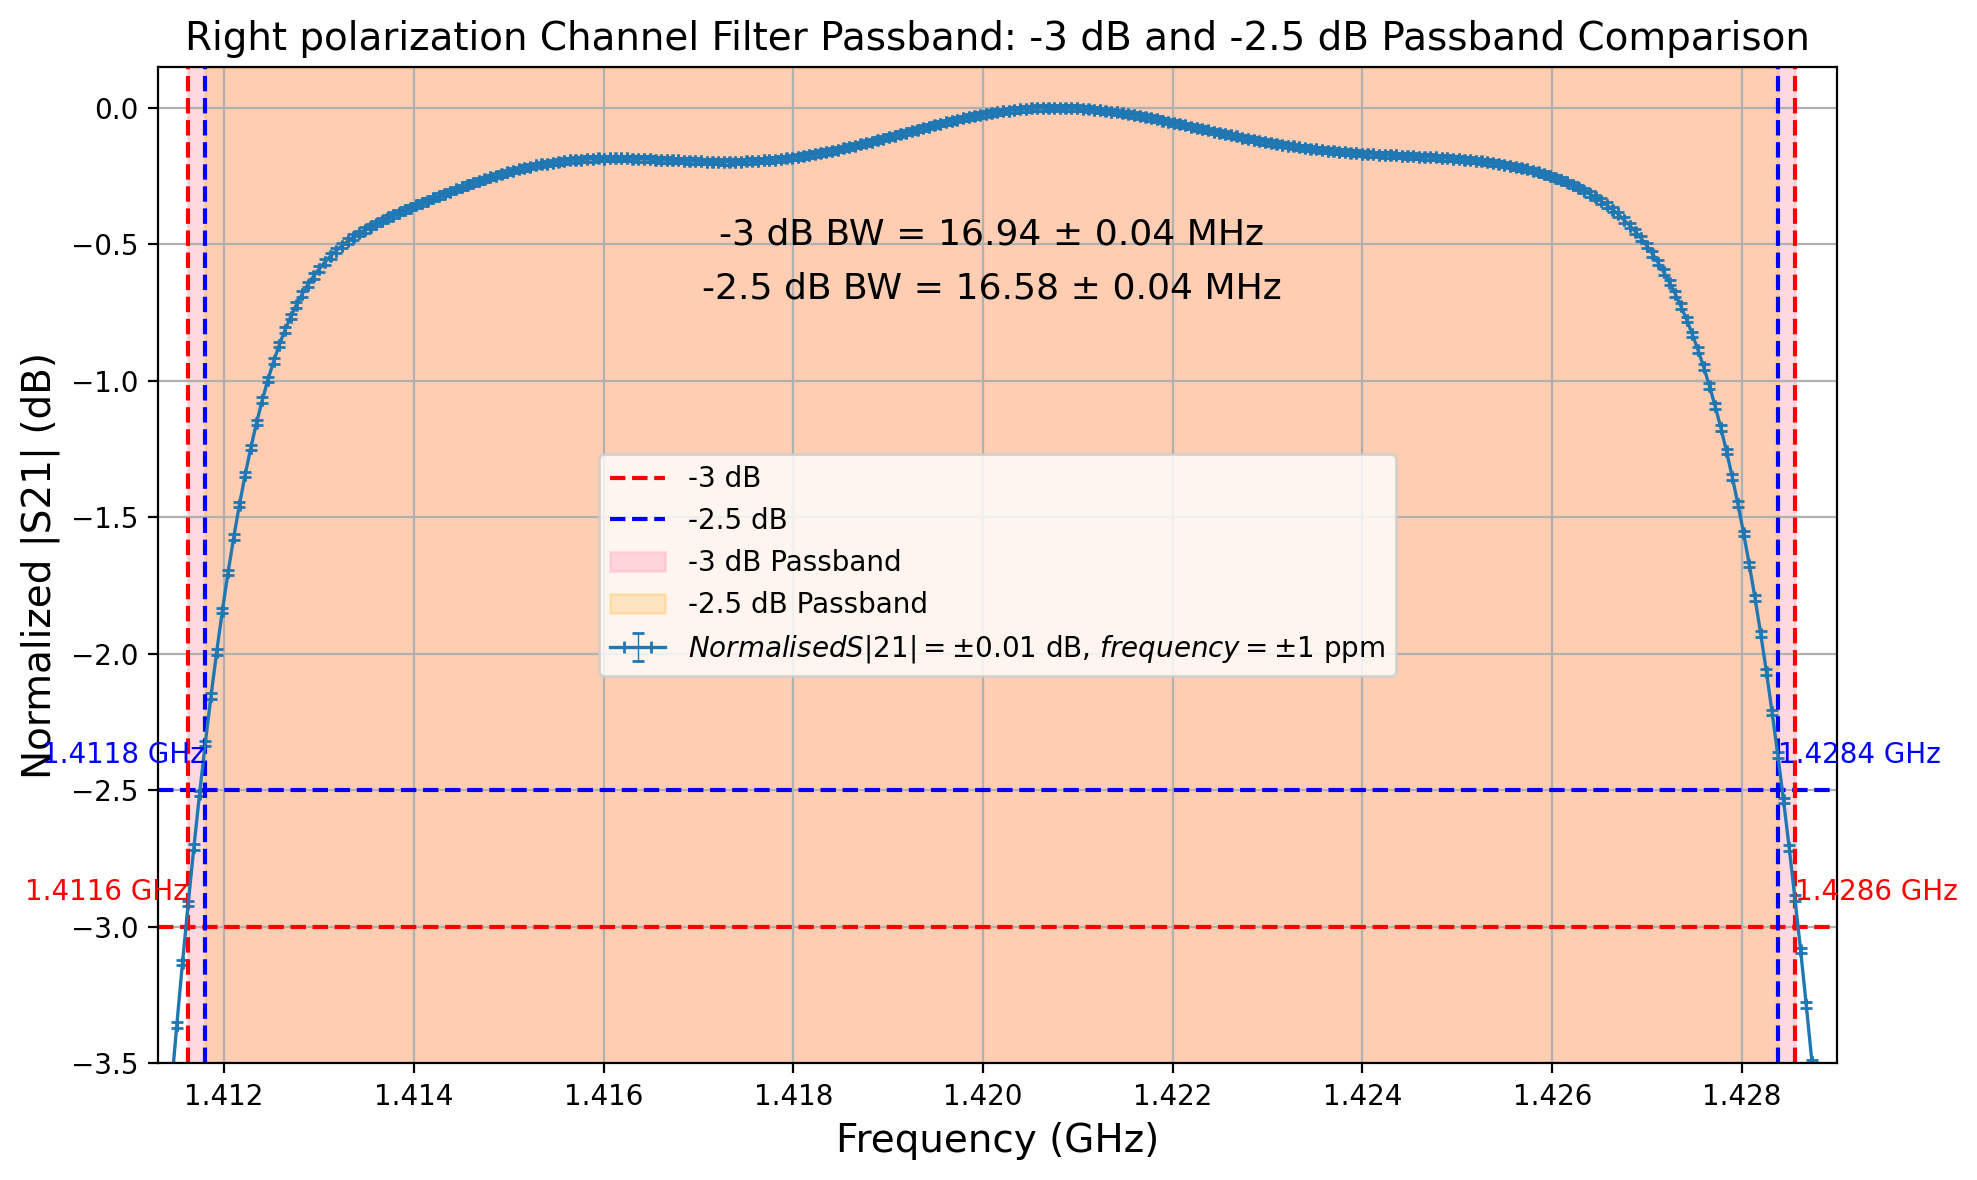

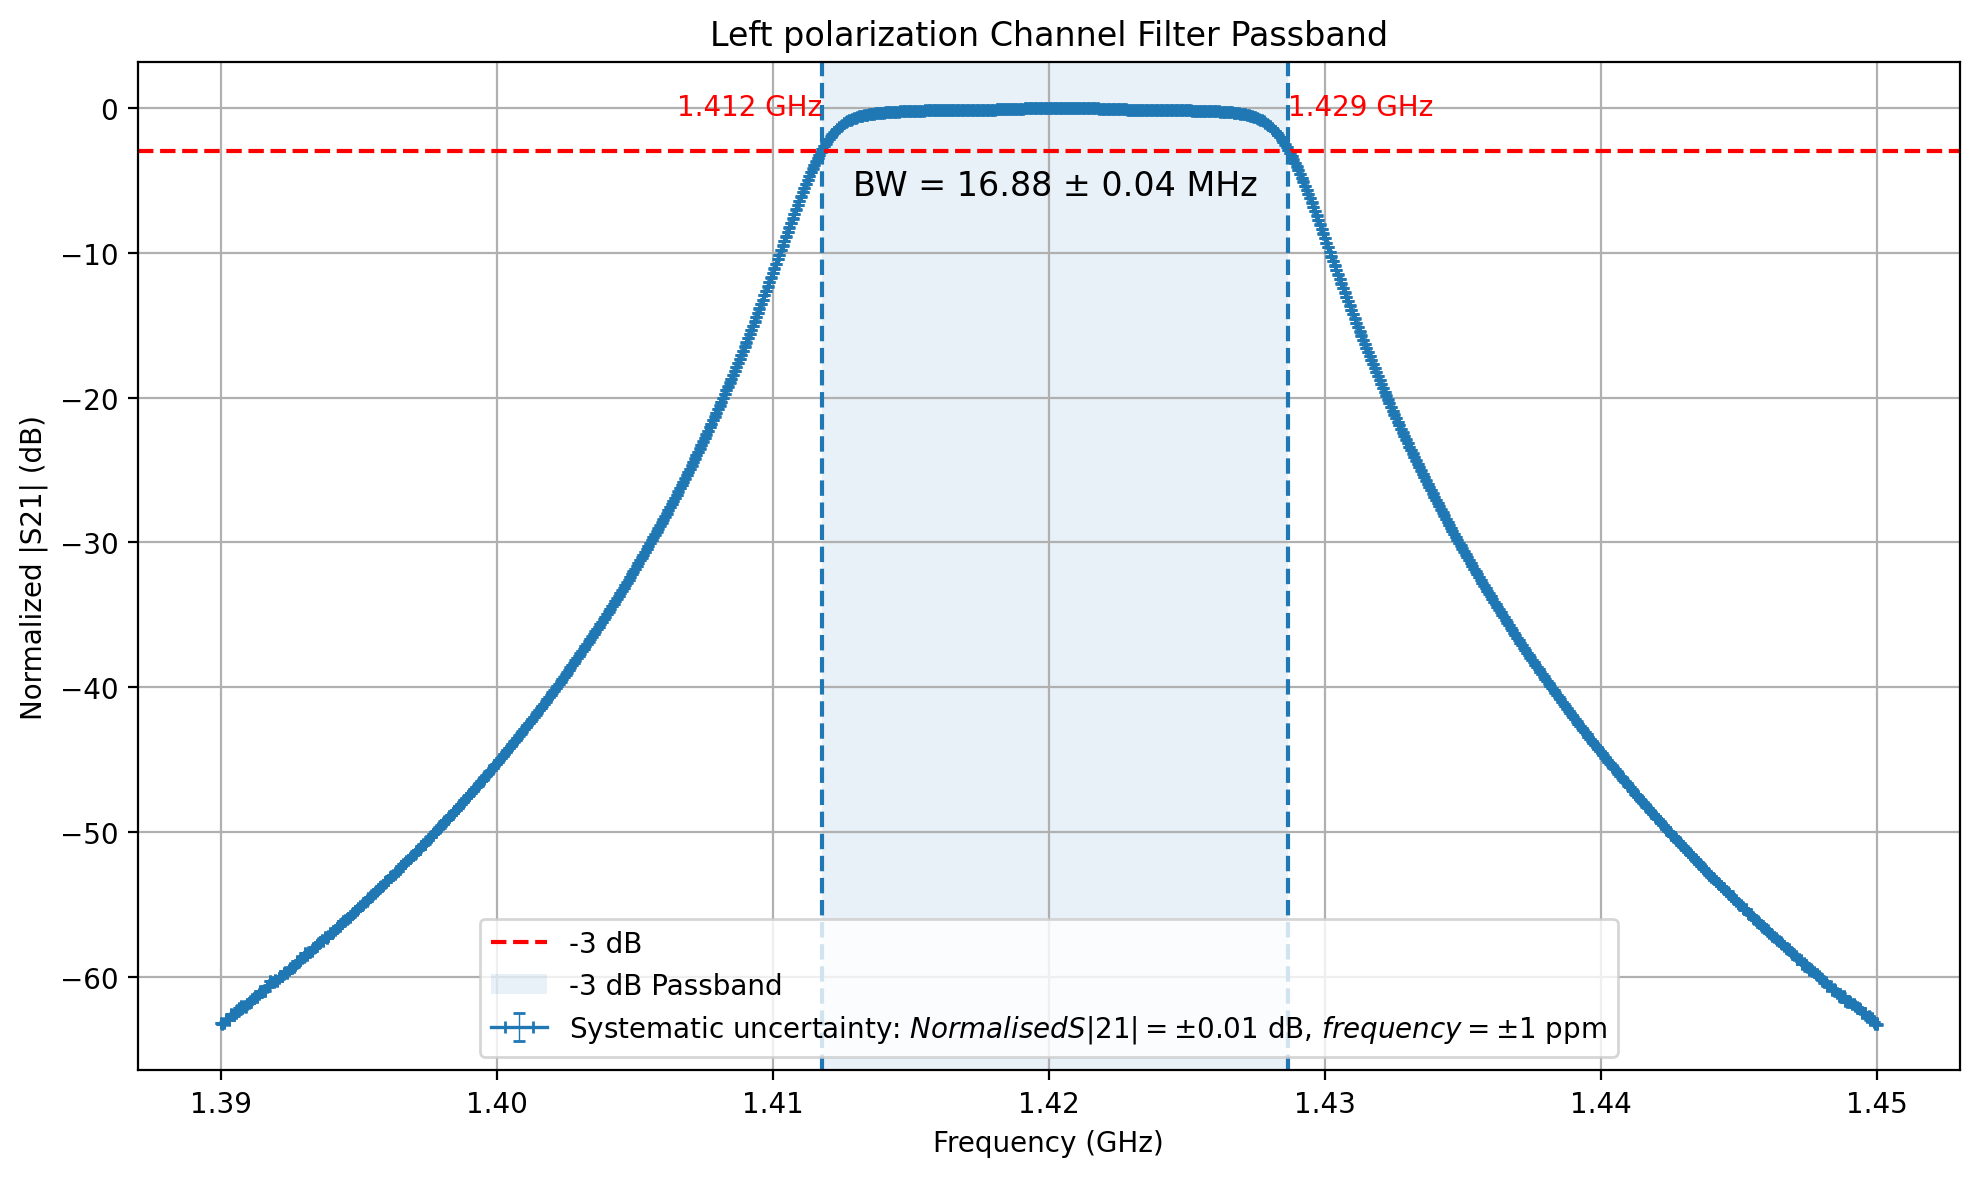

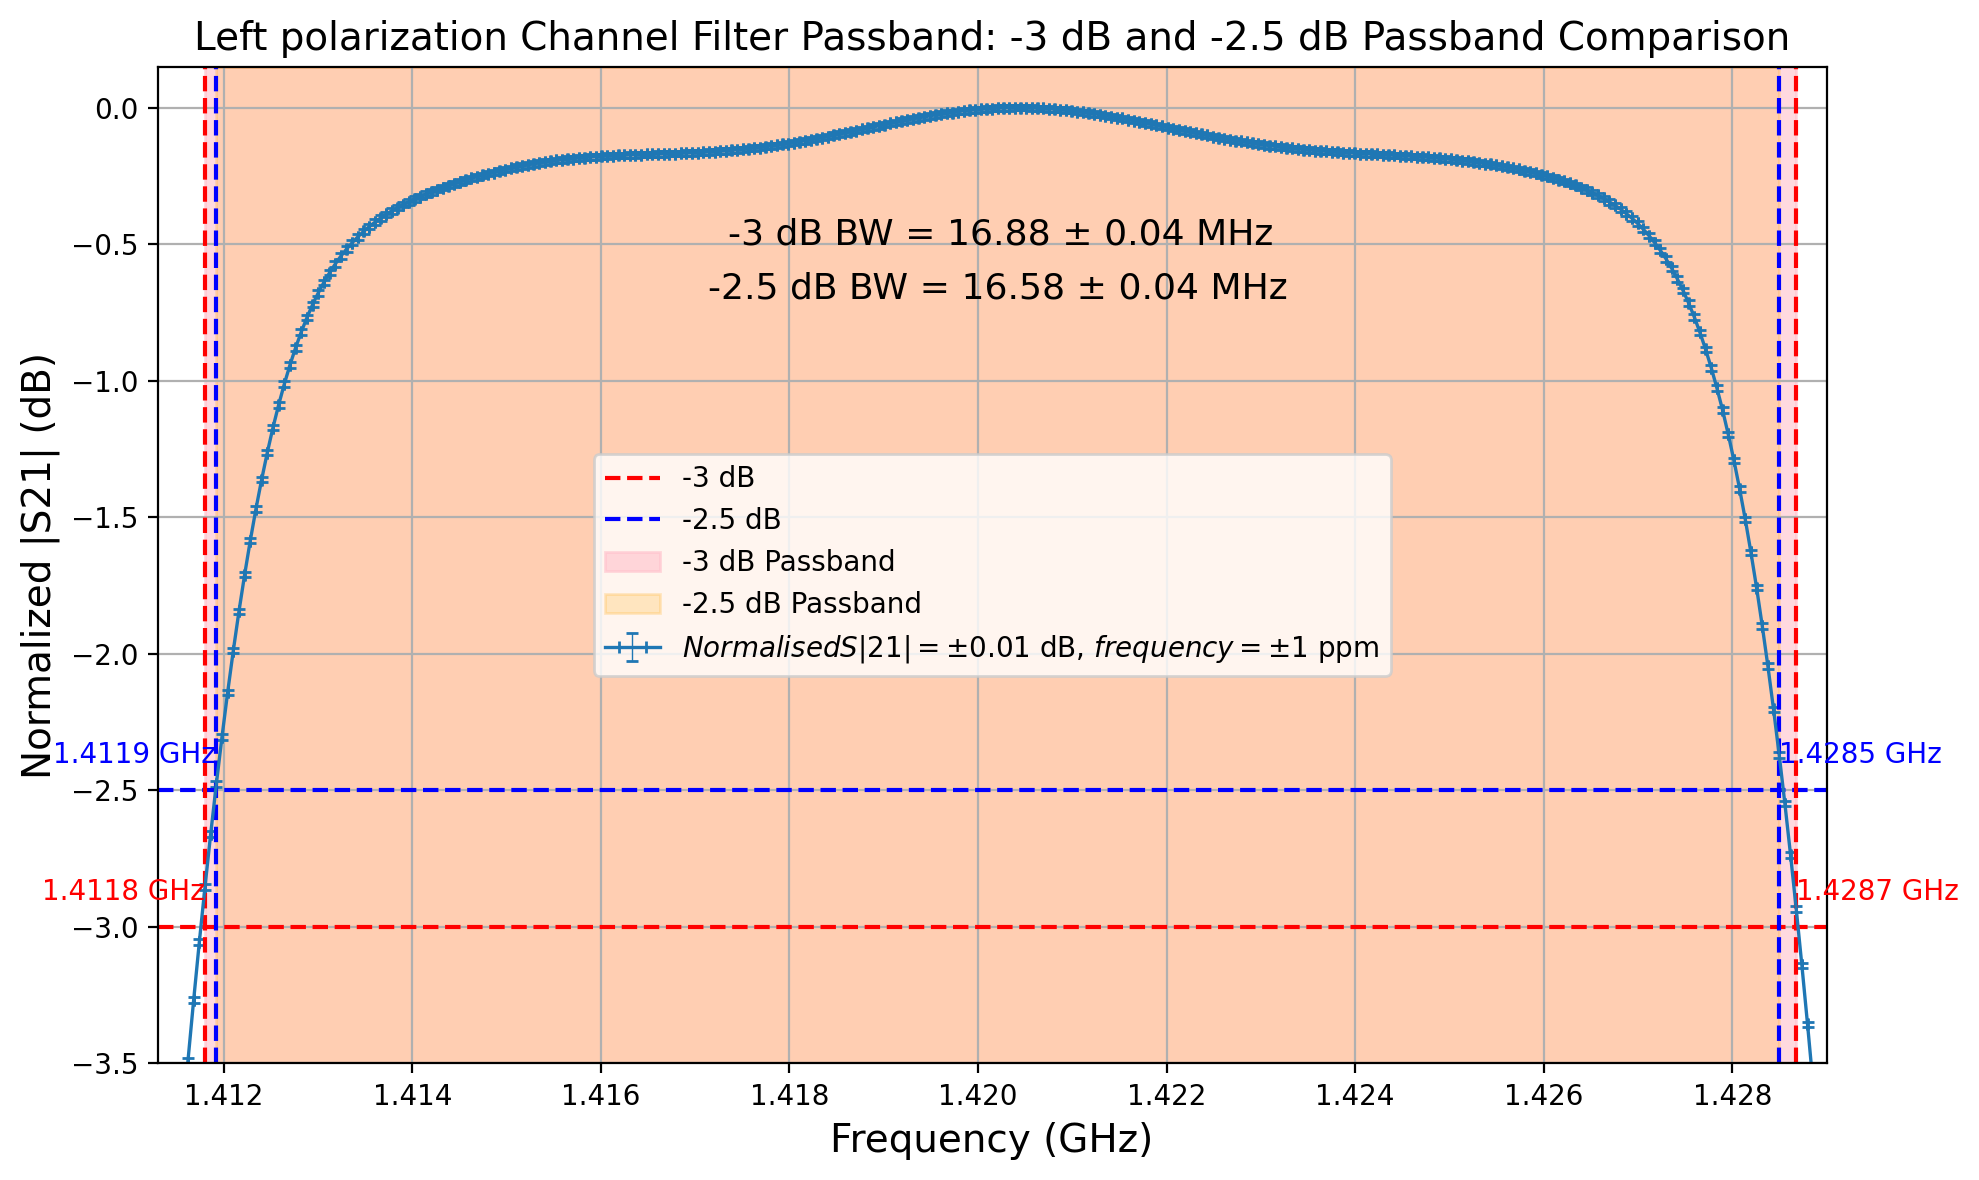

(np.float64(1.411801802801802),
 np.float64(1.428678679678679),
 np.float64(16.876876876877),
 np.float64(0.042516346436455375),
 np.float64(1.411921922921922),
 np.float64(1.428498499498498),
 np.float64(16.576576576575963),
 np.float64(0.04251634437112421))

In [13]:
plot_passband(amp1,"Right polarization Channel Filter Passband")

plot_passband(amp2,"Left polarization Channel Filter Passband")

In [9]:
df = amp2.copy()

# peak
peak_db = df["mag_dB"].max()
peak_index = df["mag_dB"].idxmax()
f_peak = df.loc[peak_index, "freq_GHz"]

# normalize
df["mag_norm_dB"] = df["mag_dB"] - peak_db

# passband
threshold = -3
passband = df[df["mag_norm_dB"] >= threshold]

f_low = passband["freq_GHz"].min()
f_high = passband["freq_GHz"].max()

# bandwidth
BW = f_high - f_low

# center frequency
f_center = (f_low + f_high) / 2

# fractional bandwidth
FBW = BW / f_center

# percent
FBW_percent = FBW * 100

print("Filter 1 Measurement Results")
print(f"Peak transmission (S21 max): {peak_db:.4f} dB")
print(f"Frequency at peak:{f_peak:.6f} GHz")
print()
print(f"Lower cutoff frequency:{f_low:.6f} GHz")
print(f"Upper cutoff frequency:{f_high:.6f} GHz")
print()
print(f"Bandwidth (BW): {BW:.6f} GHz")
print(f"Center frequency:{f_center:.6f} GHz")
print()
print(f"Fractional bandwidth:{FBW:.6f}")
print(f"Fractional bandwidth (%):{FBW_percent:.3f} %")
print()
print("Measurement error bar: ±0.0045 dB")

Filter 1 Measurement Results
Peak transmission (S21 max): -1.0466 dB
Frequency at peak:1.420450 GHz

Lower cutoff frequency:1.411802 GHz
Upper cutoff frequency:1.428679 GHz

Bandwidth (BW): 0.016877 GHz
Center frequency:1.420240 GHz

Fractional bandwidth:0.011883
Fractional bandwidth (%):1.188 %

Measurement error bar: ±0.0045 dB


In [10]:
df = amp2.copy()

# peak
peak_db = df["mag_dB"].max()
peak_index = df["mag_dB"].idxmax()
f_peak = df.loc[peak_index, "freq_GHz"]

# normalize
df["mag_norm_dB"] = df["mag_dB"] - peak_db

# passband
threshold = -3
passband = df[df["mag_norm_dB"] >= threshold]

f_low = passband["freq_GHz"].min()
f_high = passband["freq_GHz"].max()

# bandwidth
BW = f_high - f_low

# center frequency
f_center = (f_low + f_high) / 2

# fractional bandwidth
FBW = BW / f_center

# percent
FBW_percent = FBW * 100

print("Filter 1 Measurement Results")
print(f"Peak transmission (S21 max): {peak_db:.4f} dB")
print(f"Frequency at peak:{f_peak:.6f} GHz")
print()
print(f"Lower cutoff frequency:{f_low:.6f} GHz")
print(f"Upper cutoff frequency:{f_high:.6f} GHz")
print()
print(f"Bandwidth (BW): {BW:.6f} GHz")
print(f"Center frequency:{f_center:.6f} GHz")
print()
print(f"Fractional bandwidth:{FBW:.6f}")
print(f"Fractional bandwidth (%):{FBW_percent:.3f} %")
print()
print("Measurement error bar: ±0.0045 dB")

Filter 1 Measurement Results
Peak transmission (S21 max): -1.0466 dB
Frequency at peak:1.420450 GHz

Lower cutoff frequency:1.411802 GHz
Upper cutoff frequency:1.428679 GHz

Bandwidth (BW): 0.016877 GHz
Center frequency:1.420240 GHz

Fractional bandwidth:0.011883
Fractional bandwidth (%):1.188 %

Measurement error bar: ±0.0045 dB


In [11]:
df = amp1.copy()

# peak
peak_db = df["mag_dB"].max()
peak_index = df["mag_dB"].idxmax()
f_peak = df.loc[peak_index, "freq_GHz"]

# normalize
df["mag_norm_dB"] = df["mag_dB"] - peak_db

# passband
threshold = -3
passband = df[df["mag_norm_dB"] >= threshold]

f_low = passband["freq_GHz"].min()
f_high = passband["freq_GHz"].max()

# bandwidth
BW = f_high - f_low

# center frequency
f_center = (f_low + f_high) / 2

# fractional bandwidth
FBW = BW / f_center

# percent
FBW_percent = FBW * 100

print("Filter 2 Measurement Results")
print(f"Peak transmission (S21 max): {peak_db:.4f} dB")
print(f"Frequency at peak:{f_peak:.6f} GHz")
print()
print(f"Lower cutoff frequency:{f_low:.6f} GHz")
print(f"Upper cutoff frequency:{f_high:.6f} GHz")
print()
print(f"Bandwidth (BW): {BW:.6f} GHz")
print(f"Center frequency: {f_center:.6f} GHz")
print()
print(f"Fractional bandwidth:{FBW:.6f}")
print(f"Fractional bandwidth (%):{FBW_percent:.3f} %")
print()
print("Measurement error bar: ±0.0045 dB")

Filter 2 Measurement Results
Peak transmission (S21 max): -1.0905 dB
Frequency at peak:1.420691 GHz

Lower cutoff frequency:1.411622 GHz
Upper cutoff frequency:1.428559 GHz

Bandwidth (BW): 0.016937 GHz
Center frequency: 1.420090 GHz

Fractional bandwidth:0.011927
Fractional bandwidth (%):1.193 %

Measurement error bar: ±0.0045 dB
